# Unconstrained: $J=0$ vs a constant $J$, on each regularizer

The unconstrained scheme, with no projection:

$$x_{k+1}=x_k-\eta\,a(x_k)\nabla U_0(x_k)
+\eta\,\alpha\,e^{U(x_k)}J\,\nabla\psi(x_k)
+\sqrt{2\eta\,a(x_k)}\,\xi_{k+1},\qquad a(x)=e^{U(x)-U_0(x)},$$

with $U=f+g$, $U_0=f+g_0$, and $g_0$ from the closed-form piecewise-quadratic lemma. Comparison is
$\alpha=0$ against a **constant** skew $J$, on Lasso, MCP and SCAD.

## Removing $K$ removes $\psi$, and that is not a formality

In the constrained problem $\psi=(\lambda-G)h$ was pinned to the constraint set: $K=\{G\le\lambda\}$ gave it
both its zero level set and its boundary-normal gradient. With no $K$ there is no such $\psi$, and one has
to be chosen. Invariance alone is easy — for a **constant** skew $J$,
$$\nabla\!\cdot(J\nabla\psi)=\sum_{ij}J_{ij}\,\partial_i\partial_j\psi=0$$
for *any* $\psi$, antisymmetric contracted with symmetric. There is no boundary condition to satisfy,
because there is no boundary. So every $\psi$ is admissible.

**But not every $\psi$ is usable.** On a compact $K$ the factor $e^{U}$ is bounded, so the skew drift is
bounded whatever $\psi$ is. On $\mathbb R^d$, $e^{U}$ is *unbounded* — here $U\supset\tfrac12x^\top\Sigma^{-1}x$,
so $e^{U}$ grows like $e^{\lVert x\rVert^2}$. Carrying over the constrained choice $\psi=-\tfrac12\lVert
x\rVert^2$ (i.e. $\nabla\psi=-x$) gives a drift $\propto e^{U}x$ that overflows to `inf` within a few
hundred steps, which is demonstrated below rather than asserted.

The fix is to temper $\psi$ against the same exponential. Taking
$$\psi=-e^{-U_0}\quad\Longrightarrow\quad \nabla\psi=e^{-U_0}\nabla U_0
\quad\Longrightarrow\quad \alpha e^{U}J\nabla\psi=\alpha\,e^{U-U_0}J\nabla U_0=\alpha\,a(x)\,J\nabla U_0,$$
so the skew drift is bounded by the reversible one times $\alpha$, since $a\in(0,1]$. The update collapses to

$$x_{k+1}=x_k-\eta\,a(x_k)\bigl(I+\alpha J\bigr)\nabla U_0(x_k)+\sqrt{2\eta\,a(x_k)}\,\xi_{k+1},$$

which is exactly **anchored non-reversible Langevin** — the $J$ acting on $\nabla U_0$ of the early
notebooks. So the two formulations are not rivals: on a constrained set $J$ must act on $\nabla\psi$ to get
tangency, and unconstrained the natural $\psi$ puts it back on $\nabla U_0$. The apparent conflict was an
artefact of the boundary.

In [1]:
%matplotlib inline
import os, math
os.makedirs("figures", exist_ok=True)
import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance, ks_2samp

SQRT2 = math.sqrt(2.0)
INV_SQRT_2PI = 1.0 / math.sqrt(2.0 * math.pi)
def Phi(u): return 0.5 * (1.0 + torch.erf(u / SQRT2))
def phi(u): return INV_SQRT_2PI * torch.exp(-0.5 * u * u)
def PhiX(u):
    fin = torch.isfinite(u)
    step = torch.where(u > 0, torch.ones_like(u), torch.zeros_like(u))
    return torch.where(fin, Phi(torch.where(fin, u, torch.zeros_like(u))), step)
def phiX(u):
    fin = torch.isfinite(u)
    return torch.where(fin, phi(torch.where(fin, u, torch.zeros_like(u))), torch.zeros_like(u))
def uphiX(u):
    fin = torch.isfinite(u)
    uu = torch.where(fin, u, torch.zeros_like(u))
    return torch.where(fin, uu * phi(uu), torch.zeros_like(u))

## The closed-form smoothing lemma

For $p$ continuous and piecewise quadratic with $p(t)=c_{0,j}+c_{1,j}t+c_{2,j}t^2$ on $(t_j,t_{j+1})$, and
$u_j=(t_j-x)/\mu$,

$$P_j=\Phi(u_{j+1})-\Phi(u_j),\quad M_j=\phi(u_j)-\phi(u_{j+1}),\quad
Q_j=P_j+u_j\phi(u_j)-u_{j+1}\phi(u_{j+1}),$$

$$p_0(x)=\sum_j\Bigl\{(c_{0,j}+c_{1,j}x+c_{2,j}x^2)P_j+\mu(c_{1,j}+2c_{2,j}x)M_j+c_{2,j}\mu^2Q_j\Bigr\},
\qquad
p_0'(x)=\sum_j\Bigl\{(c_{1,j}+2c_{2,j}x)P_j+2c_{2,j}\mu M_j\Bigr\}.$$

One generic implementation covers all three regularizers; only the breakpoint/coefficient table changes.

In [2]:
class PiecewiseQuadratic:
    def __init__(self, breaks, coefs, name=""):
        self.t = list(breaks); self.c = [tuple(map(float, c)) for c in coefs]; self.name = name
        assert len(self.c) == len(self.t) + 1

    def raw(self, x):                       # the exact, non-differentiable penalty
        out = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            m = (x > ts[j]) & (x <= ts[j + 1])
            out = torch.where(m, c0 + c1 * x + c2 * x * x, out)
        return out

    def smooth(self, x, mu):                # (p0, p0') in closed form
        val = torch.zeros_like(x); grad = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            uj  = torch.full_like(x, -math.inf) if ts[j]     == -math.inf else (ts[j]     - x) / mu
            uj1 = torch.full_like(x,  math.inf) if ts[j + 1] ==  math.inf else (ts[j + 1] - x) / mu
            P = PhiX(uj1) - PhiX(uj)
            M = phiX(uj) - phiX(uj1)
            Q = P + uphiX(uj) - uphiX(uj1)
            val  = val  + (c0 + c1 * x + c2 * x * x) * P + mu * (c1 + 2 * c2 * x) * M + c2 * mu ** 2 * Q
            grad = grad + (c1 + 2 * c2 * x) * P + 2 * c2 * mu * M
        return val, grad

def lasso(lam):
    return PiecewiseQuadratic([0.0], [(0., -lam, 0.), (0., lam, 0.)], "Lasso")

def mcp(lam, a):
    return PiecewiseQuadratic([-a*lam, 0.0, a*lam],
        [(a*lam**2/2, 0., 0.), (0., -lam, -1/(2*a)), (0., lam, -1/(2*a)), (a*lam**2/2, 0., 0.)], "MCP")

def scad(lam, a):
    c = 1.0 / (2 * (a - 1))
    return PiecewiseQuadratic([-a*lam, -lam, 0.0, lam, a*lam],
        [(lam**2*(a+1)/2, 0., 0.), (-lam**2*c, -2*a*lam*c, -c), (0., -lam, 0.),
         (0., lam, 0.), (-lam**2*c, 2*a*lam*c, -c), (lam**2*(a+1)/2, 0., 0.)], "SCAD")

In [3]:
# --- the closed forms are checked against Monte Carlo and against finite differences
LAM, AA, MU = 1.0, 3.0, 0.3
xg = torch.linspace(-4, 4, 41)
torch.manual_seed(0); Z = torch.randn(2_000_000)
print("{:<7}{:>26}{:>28}{:>22}".format("", "max |closed - MC|", "max |p0' - d/dx p0|", "MC std err"))
print("-" * 84)
for P in [lasso(LAM), mcp(LAM, AA), scad(LAM, AA)]:
    v, g = P.smooth(xg, MU)
    vmc = torch.stack([P.raw(xi + MU * Z).mean() for xi in xg])
    se  = float(torch.stack([P.raw(xi + MU * Z).std() for xi in xg]).max() / math.sqrt(len(Z)))
    h = 1e-5
    vp, _ = P.smooth(xg + h, MU); vm, _ = P.smooth(xg - h, MU)
    print("{:<7}{:>26.2e}{:>28.2e}{:>22.2e}".format(
        P.name, float((v - vmc).abs().max()), float((g - (vp - vm) / (2 * h)).abs().max()), se))
print("\n(the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed)")

                max |closed - MC|         max |p0' - d/dx p0|            MC std err
------------------------------------------------------------------------------------


Lasso                    1.93e-04                    7.92e-11              2.12e-04


MCP                      1.75e-04                    8.15e-11              1.62e-04


SCAD                     1.93e-04                    8.46e-11              2.06e-04

(the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed)


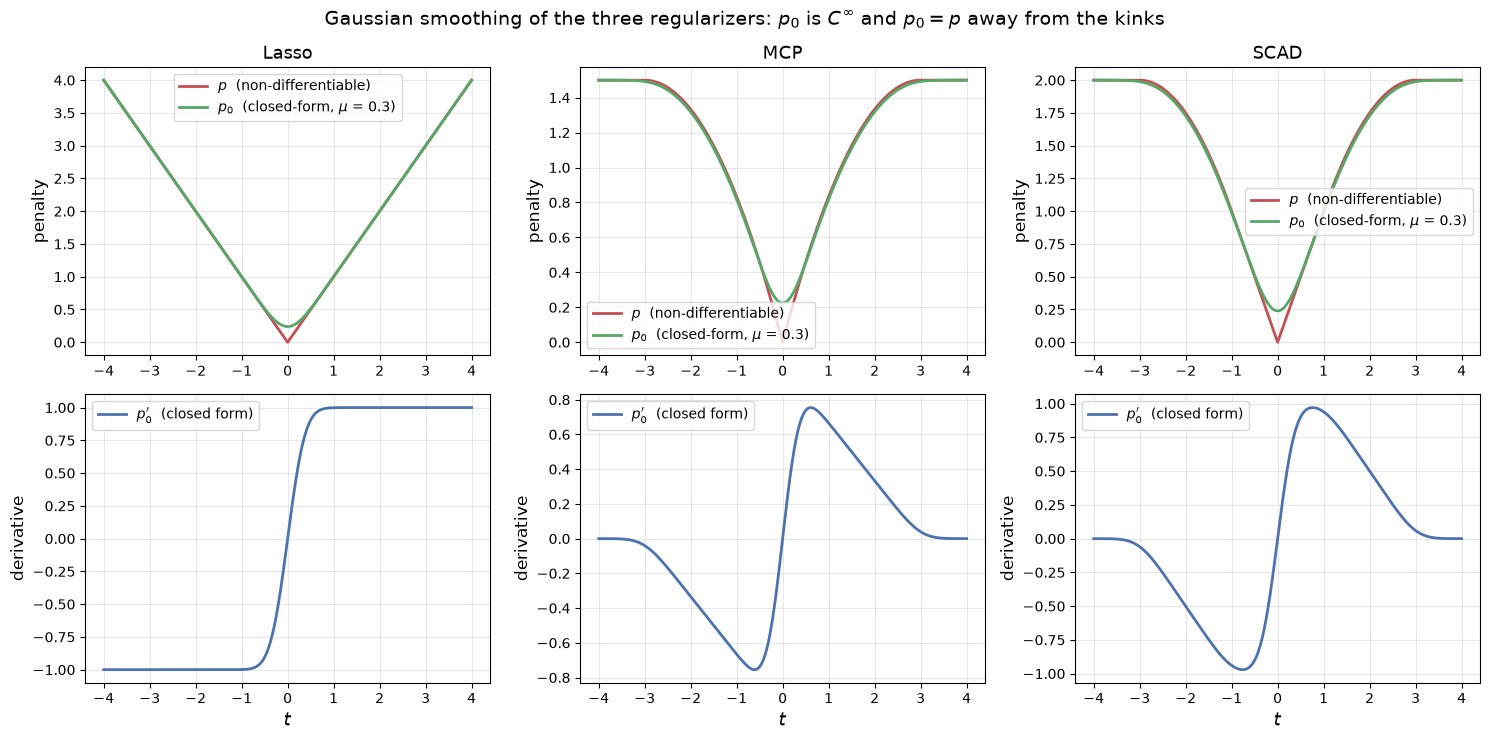

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
tt = torch.linspace(-4, 4, 601)
for j, P in enumerate([lasso(LAM), mcp(LAM, AA), scad(LAM, AA)]):
    v, g = P.smooth(tt, MU)
    axes[0, j].plot(tt, P.raw(tt), linewidth=2, color="#C44E52", label="$p$  (non-differentiable)")
    axes[0, j].plot(tt, v, linewidth=2, color="#55A868", label=r"$p_0$  (closed-form, $\mu$ = 0.3)")
    axes[0, j].set_title(P.name, fontsize=13); axes[0, j].grid(alpha=0.3); axes[0, j].legend(fontsize=10)
    axes[0, j].set_ylabel("penalty", fontsize=12)
    axes[1, j].plot(tt, g, linewidth=2, color="#4C72B0", label="$p_0'$  (closed form)")
    axes[1, j].set_xlabel("$t$", fontsize=13); axes[1, j].set_ylabel("derivative", fontsize=12)
    axes[1, j].grid(alpha=0.3); axes[1, j].legend(fontsize=10)
fig.suptitle(r"Gaussian smoothing of the three regularizers: $p_0$ is $C^\infty$ and $p_0=p$ away from the kinks",
             fontsize=14)
plt.tight_layout()
plt.savefig("figures/pq_penalties.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# -----------------------------
# Target and EXACT unconstrained reference
#   U = f + g,  f = 1/2 x' Sinv x,  U0 = f + g0,  a = e^{U-U0} = e^{g-g0}
#   pi ~ e^{-f-g} on all of R^3;  g >= 0, so rejection from N(0,Sigma) accepting w.p. e^{-g} is exact
# -----------------------------
d = 3
N, ETA, MAXIT = 4000, 1e-3, 6000
SEEDS = [11, 22, 33]
x_start = 0.5

def make_Sigma(scales, rho):
    Dm = np.diag(scales); Cm = np.full((d, d), rho); np.fill_diagonal(Cm, 1.0)
    return Dm @ Cm @ Dm
SIGMA = make_Sigma([0.8, 1.2, 2.0], 0.5)
EVAL, EVEC = np.linalg.eigh(SIGMA)

class Target:
    def __init__(self, pen, Sigma=SIGMA, mu=MU):
        self.pen, self.mu = pen, mu
        self.Sinv = torch.tensor(np.linalg.inv(Sigma))
        self.L = torch.tensor(np.linalg.cholesky(Sigma))
    def f(self, x):  return 0.5 * ((x @ self.Sinv) * x).sum(1)
    def g(self, x):  return self.pen.raw(x).sum(1)
    def U(self, x):  return self.f(x) + self.g(x)
    def U0_and_grad(self, x):
        v, gr = self.pen.smooth(x, self.mu)
        return self.f(x) + v.sum(1), x @ self.Sinv + gr

def sample_target(T, n, rng, batch=200_000):
    out = []
    while len(out) < n:
        z = torch.tensor(rng.normal(size=(batch, d))) @ T.L.T
        acc = torch.tensor(rng.random(len(z))) < torch.exp(-T.g(z))
        out.extend(z[acc].tolist())
    return np.array(out[:n])

def J_from_axis(w):
    w = np.asarray(w, float); w = w / np.linalg.norm(w)
    return torch.tensor([[0., -w[2], w[1]], [w[2], 0., -w[0]], [-w[1], w[0], 0.]])
J_TRI   = torch.tensor([[0., 1., 0.], [-1., 0., 1.], [0., -1., 0.]])
J_ALIGN = J_from_axis(EVEC[:, 0])
print("Sigma eigenvalues", np.round(EVAL, 3), "  cond {:.1f}".format(EVAL[-1] / EVAL[0]))
print("aligned axis (smallest-variance eigenvector) =", np.round(EVEC[:, 0], 3))

Sigma eigenvalues [0.392 1.004 4.684]   cond 11.9
aligned axis (smallest-variance eigenvector) = [ 0.944 -0.311 -0.106]


## The two $\psi$ choices, side by side

`quad` is the naive carry-over $\nabla\psi=-x$; `tempered` is $\psi=-e^{-U_0}$. Both are admissible
(constant skew $\Rightarrow$ divergence-free for any $\psi$); only one is usable.

In [6]:
@torch.no_grad()
def run_chain(T, alpha, ref, seed=11, J=J_ALIGN, psi="tempered", n_steps=MAXIT, eta=ETA, N=N,
              every=10, track=True):
    torch.manual_seed(seed)
    x = torch.full((N, d), x_start)
    it, W, mx, blew = [], [], 0.0, False
    for k in range(n_steps):
        al = alpha[1] * max(0.0, 1.0 - k / alpha[2]) if isinstance(alpha, tuple) else float(alpha)
        U0, gU0 = T.U0_and_grad(x)
        Uv = T.U(x)
        a = torch.exp(Uv - U0)
        step = -eta * a.unsqueeze(1) * gU0
        if al != 0.0:
            if psi == "tempered":                       # e^U * e^{-U0} = a(x)
                skew = al * a.unsqueeze(1) * (gU0 @ J.T)
            else:                                       # grad psi = -x, drift ~ e^U x
                skew = al * torch.exp(Uv).unsqueeze(1) * ((-x) @ J.T)
            step = step + eta * skew
            mx = max(mx, float((eta * skew).norm(dim=1).max()))
        x = x + step + torch.sqrt(2 * eta * a).unsqueeze(1) * torch.randn_like(x)
        if not torch.isfinite(x).all():
            blew = True; break
        if track and (k + 1) % every == 0:
            xn = x.numpy(); it.append(k + 1)
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), np.array(it), (np.array(W) if track else None), mx, blew

def ensemble(T, alpha, ref, seeds=SEEDS, **kw):
    C, X, it, W1 = [], None, None, None
    for j, sd in enumerate(seeds):
        X, it, W, mx, blew = run_chain(T, alpha, ref, seed=sd, **kw)
        if j == 0: W1 = W
        C.append(W.mean(axis=1))
    return it, np.array(C), X, W1

def tau(it, c, eps):
    bad = np.where(c > eps)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return np.nan if j >= len(it) else float(it[j])

def tau_mean(it, C, eps):
    v = [tau(it, c, eps) for c in C]
    return float(np.nanmean(v)) if np.any(np.isfinite(v)) else np.nan

In [7]:
PENS = {"Lasso": lasso(LAM), "MCP": mcp(LAM, AA), "SCAD": scad(LAM, AA)}
TARGETS, refs, floors = {}, {}, {}
rng = np.random.default_rng(7)
for nm, pen in PENS.items():
    T = Target(pen); TARGETS[nm] = T
    refs[nm] = sample_target(T, N, rng)
    floors[nm] = float(np.mean([[wasserstein_distance(refs[nm][:, i], sample_target(T, N, rng)[:, i])
                                 for i in range(d)] for _ in range(4)]))
    r = np.linalg.norm(refs[nm], axis=1)
    print("{:<6} floor {:.4f}   ||x||: median {:.2f}  q99 {:.2f}  max {:.2f}".format(
        nm, floors[nm], np.median(r), np.quantile(r, .99), r.max()))

T = TARGETS["Lasso"]
xt = torch.tensor(refs["Lasso"]); U0t, _ = T.U0_and_grad(xt); Ut = T.U(xt)
print("\ne^U over the Lasso target: median {:.1f}   q99 {:.1e}   max {:.1e}   (UNBOUNDED on R^3)".format(
    float(Ut.exp().median()), float(Ut.exp().quantile(.99)), float(Ut.exp().max())))
print("a(x) = e^(U-U0):           min {:.3f}   max {:.3f}   (bounded, this is what 'tempered' uses)".format(
    float((Ut - U0t).exp().min()), float((Ut - U0t).exp().max())))
print()
for psi in ["quad", "tempered"]:
    X, it, W, mx, blew = run_chain(T, 2.0, refs["Lasso"], psi=psi, n_steps=400, every=100)
    print("psi = {:<9} diverged: {:<6}  max |eta * skew step| = {:.3e}".format(psi, str(blew), mx))
print("\n-> both are invariance-admissible; only the tempered one is numerically usable off a compact set")

Lasso  floor 0.0230   ||x||: median 1.02  q99 3.13  max 5.19


MCP    floor 0.0286   ||x||: median 1.26  q99 4.44  max 6.69


SCAD   floor 0.0250   ||x||: median 1.10  q99 4.22  max 5.66

e^U over the Lasso target: median 7.4   q99 1.7e+03   max 4.9e+05   (UNBOUNDED on R^3)
a(x) = e^(U-U0):           min 0.507   max 1.000   (bounded, this is what 'tempered' uses)



psi = quad      diverged: True    max |eta * skew step| = inf


psi = tempered  diverged: False   max |eta * skew step| = 7.522e-03

-> both are invariance-admissible; only the tempered one is numerically usable off a compact set


## Experiment 1 — tune the constant $J$

Two knobs: the rotation axis and $\alpha$. Unconstrained there is no boundary condition, so **every**
constant skew is admissible and the axis is purely a rate choice. As in the constrained case, the axis
should be the smallest-variance eigenvector of $\Sigma$, leaving the rotation plane spanned by the two
slowest directions.

In [8]:
EPS = (0.15, 0.10, 0.06)
it0, C0, X0, _ = ensemble(T, 0.0, refs["Lasso"])
base = {e: tau_mean(it0, C0, e) for e in EPS}
print("Lasso, floor {:.4f};  J = 0 gives tau = {:.0f} / {:.0f} / {:.0f}, W1@500 {:.4f}, W1@6000 {:.4f}\n".format(
    floors["Lasso"], base[0.15], base[0.10], base[0.06],
    C0.mean(axis=0)[49], C0.mean(axis=0)[-10:].mean()))
print("{:<14}{:<22}{:>16}{:>16}{:>16}{:>20}".format(
    "axis", "alpha", "tau(0.15)", "tau(0.10)", "tau(0.06)", "W1 @ 500 iters"))
print("-" * 104)
for anm, J in [("tridiagonal", J_TRI), ("aligned", J_ALIGN)]:
    for al in [2.0, 4.0, ("lin", 4.0, 1500)]:
        it, C, X, _ = ensemble(T, al, refs["Lasso"], J=J)
        m, sv = C.mean(axis=0), C.std(axis=0)
        cells = []
        for e in EPS:
            v = tau_mean(it, C, e)
            cells.append("{:.0f} ({:.1f}x)".format(v, base[e] / v) if np.isfinite(v) else "n/a")
        lab = "annealed {:.0f} -> 0 / {}".format(al[1], al[2]) if isinstance(al, tuple) else str(al)
        print("{:<14}{:<22}{:>16}{:>16}{:>16}{:>20}".format(
            anm, lab, cells[0], cells[1], cells[2], "{:.4f}+-{:.4f}".format(m[49], sv[49])))

Lasso, floor 0.0230;  J = 0 gives tau = 1027 / 1497 / 2293, W1@500 0.2549, W1@6000 0.0238

axis          alpha                        tau(0.15)       tau(0.10)       tau(0.06)      W1 @ 500 iters
--------------------------------------------------------------------------------------------------------


tridiagonal   2.0                         627 (1.6x)     1173 (1.3x)     1810 (1.3x)      0.1554+-0.0050


tridiagonal   4.0                         630 (1.6x)     1150 (1.3x)     1803 (1.3x)      0.2307+-0.0030


tridiagonal   annealed 4 -> 0 / 1500      790 (1.3x)     1140 (1.3x)     2023 (1.1x)      0.2344+-0.0050


aligned       2.0                         613 (1.7x)      770 (1.9x)     1030 (2.2x)      0.1868+-0.0037


aligned       4.0                         607 (1.7x)      903 (1.7x)     1280 (1.8x)      0.1718+-0.0018


aligned       annealed 4 -> 0 / 1500      473 (2.2x)      847 (1.8x)     1200 (1.9x)      0.1447+-0.0022


## Experiment 2 — $J=0$ vs constant $J$, on every regularizer

These are the requested curves. Horizon 6000 iterations: the unconstrained target is much wider than the
constrained one ($\lVert x\rVert$ reaching $\sim5$ against $1.5$), so 2000 iterations is not enough for
$J=0$ to converge and a stationary comparison at that horizon would be meaningless.

In [9]:
CASES = [("J = 0", 0.0), ("constant J, alpha = 2", 2.0), ("constant J, annealed 4 -> 0", ("lin", 4.0, 1500))]
final = {}
for nm in PENS:
    Tn = TARGETS[nm]
    print("\n### {} (unconstrained)   floor {:.4f}".format(nm, floors[nm]))
    print("{:<30}{:>16}{:>16}{:>16}{:>20}{:>20}".format(
        "scheme", "tau(0.15)", "tau(0.10)", "tau(0.06)", "W1 @ 500 iters", "W1 @ 6000"))
    print("-" * 118)
    base, final[nm] = {}, {}
    for lab, al in CASES:
        it, C, X, W1 = ensemble(Tn, al, refs[nm], J=J_ALIGN)
        m, sv = C.mean(axis=0), C.std(axis=0)
        cells = []
        for e in EPS:
            v = tau_mean(it, C, e)
            if al == 0.0: base[e] = v
            cells.append("{:.0f} ({:.1f}x)".format(v, base[e] / v) if np.isfinite(v) else "n/a")
        final[nm][lab] = {"it": it, "C": C, "x": X, "W1": W1}
        print("{:<30}{:>16}{:>16}{:>16}{:>20}{:>20}".format(
            lab, cells[0], cells[1], cells[2], "{:.4f}+-{:.4f}".format(m[49], sv[49]),
            "{:.4f}+-{:.4f}".format(m[-10:].mean(), sv[-10:].mean())))


### Lasso (unconstrained)   floor 0.0230
scheme                               tau(0.15)       tau(0.10)       tau(0.06)      W1 @ 500 iters           W1 @ 6000
----------------------------------------------------------------------------------------------------------------------


J = 0                              1027 (1.0x)     1497 (1.0x)     2293 (1.0x)      0.2549+-0.0033      0.0238+-0.0052


constant J, alpha = 2               613 (1.7x)      770 (1.9x)     1030 (2.2x)      0.1868+-0.0037      0.0246+-0.0022


constant J, annealed 4 -> 0         473 (2.2x)      847 (1.8x)     1200 (1.9x)      0.1447+-0.0022      0.0232+-0.0050

### MCP (unconstrained)   floor 0.0286
scheme                               tau(0.15)       tau(0.10)       tau(0.06)      W1 @ 500 iters           W1 @ 6000
----------------------------------------------------------------------------------------------------------------------


J = 0                              1460 (1.0x)     2197 (1.0x)     3543 (1.0x)      0.3209+-0.0022      0.0271+-0.0018


constant J, alpha = 2               953 (1.5x)     1317 (1.7x)     1857 (1.9x)      0.2660+-0.0027      0.0296+-0.0019


constant J, annealed 4 -> 0         973 (1.5x)     1413 (1.6x)     2480 (1.4x)      0.2325+-0.0006      0.0296+-0.0022

### SCAD (unconstrained)   floor 0.0250
scheme                               tau(0.15)       tau(0.10)       tau(0.06)      W1 @ 500 iters           W1 @ 6000
----------------------------------------------------------------------------------------------------------------------


J = 0                              1070 (1.0x)     1543 (1.0x)     2277 (1.0x)      0.2685+-0.0023      0.0207+-0.0012


constant J, alpha = 2               713 (1.5x)     1000 (1.5x)     1567 (1.5x)      0.2070+-0.0028      0.0236+-0.0027


constant J, annealed 4 -> 0         800 (1.3x)     1070 (1.4x)     1780 (1.3x)      0.1914+-0.0031      0.0284+-0.0032


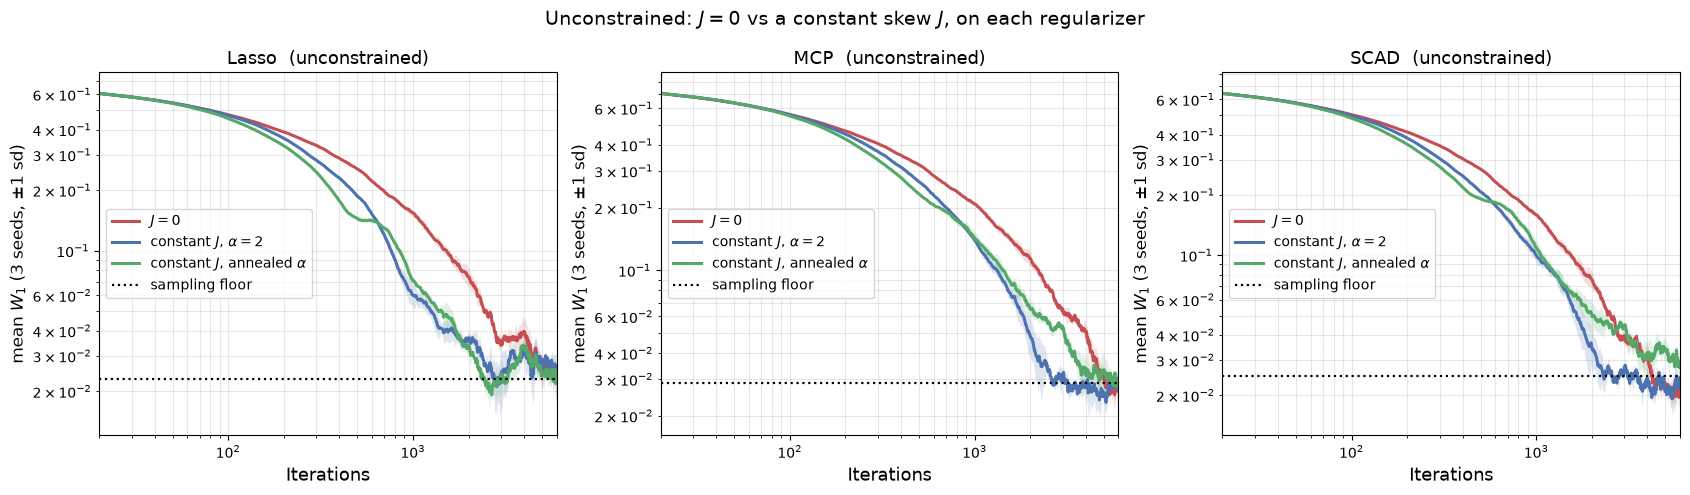

In [10]:
LAB = [c[0] for c in CASES]
CB = {LAB[0]: "#C44E52", LAB[1]: "#4C72B0", LAB[2]: "#55A868"}
SH = {LAB[0]: "$J = 0$", LAB[1]: r"constant $J$, $\alpha=2$", LAB[2]: r"constant $J$, annealed $\alpha$"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, nm in zip(axes, PENS):
    for lab in LAB:
        r = final[nm][lab]
        m, sv = r["C"].mean(axis=0), r["C"].std(axis=0)
        ax.plot(r["it"], m, linewidth=2.2, color=CB[lab], label=SH[lab])
        ax.fill_between(r["it"], m - sv, m + sv, color=CB[lab], alpha=0.18, linewidth=0)
    ax.axhline(floors[nm], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(20, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel("mean $W_1$ (3 seeds, $\\pm$1 sd)", fontsize=12)
    ax.set_title(nm + "  (unconstrained)", fontsize=13)
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=10)
fig.suptitle(r"Unconstrained: $J=0$ vs a constant skew $J$, on each regularizer", fontsize=14)
plt.tight_layout()
plt.savefig("figures/unc_headtohead.pdf", dpi=300, bbox_inches="tight")
plt.show()

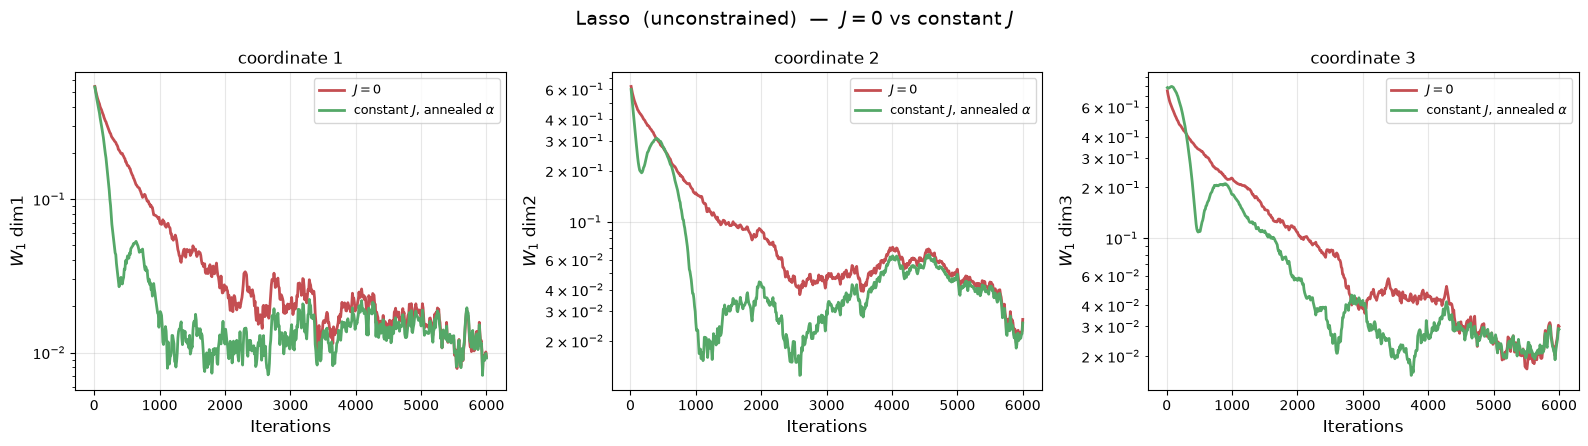

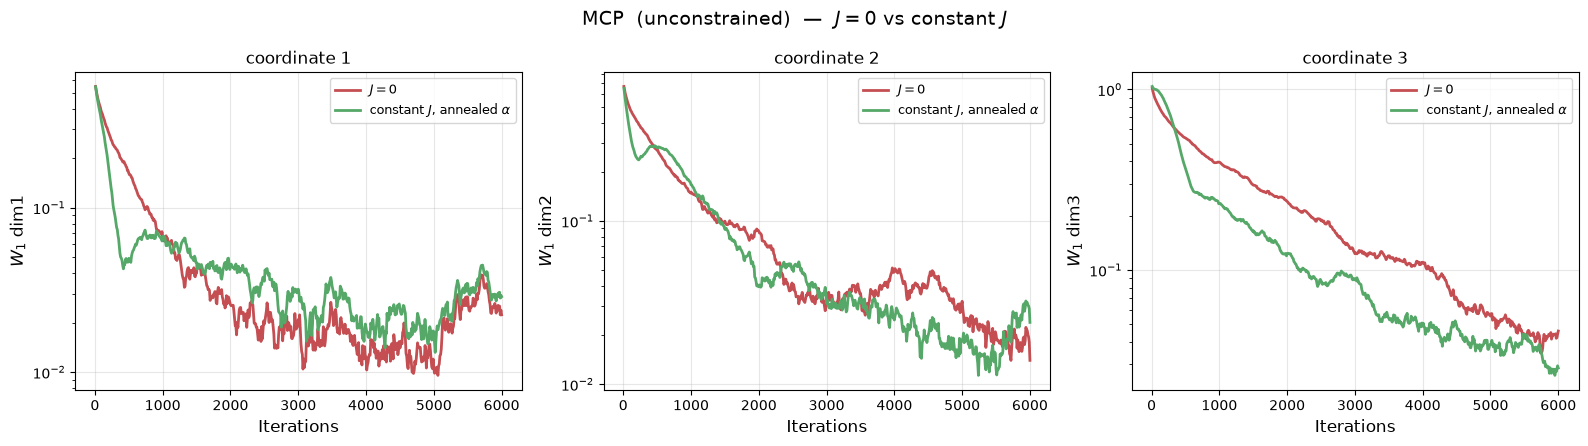

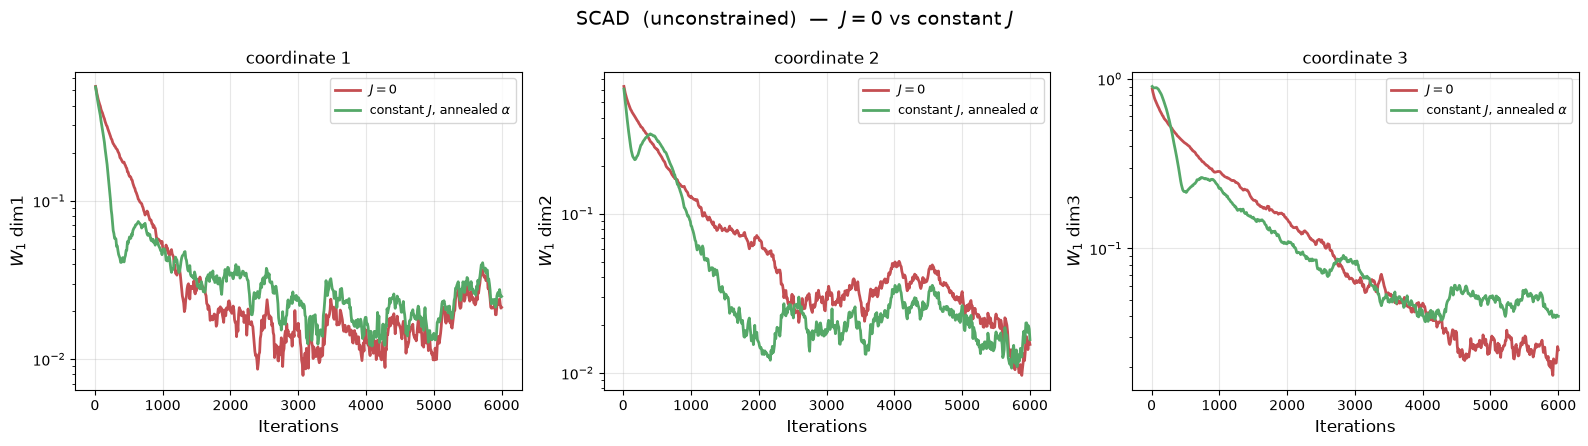

In [11]:
for nm in PENS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for i, ax in enumerate(axes):
        for lab in [LAB[0], LAB[2]]:
            r = final[nm][lab]
            ax.plot(r["it"], r["W1"][:, i], linewidth=2, color=CB[lab], label=SH[lab])
        ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=12)
        ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=12)
        ax.set_title("coordinate {}".format(i + 1), fontsize=12)
        ax.grid(alpha=0.3); ax.legend(fontsize=9)
    fig.suptitle(nm + r"  (unconstrained)  —  $J=0$ vs constant $J$", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/unc_w1_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

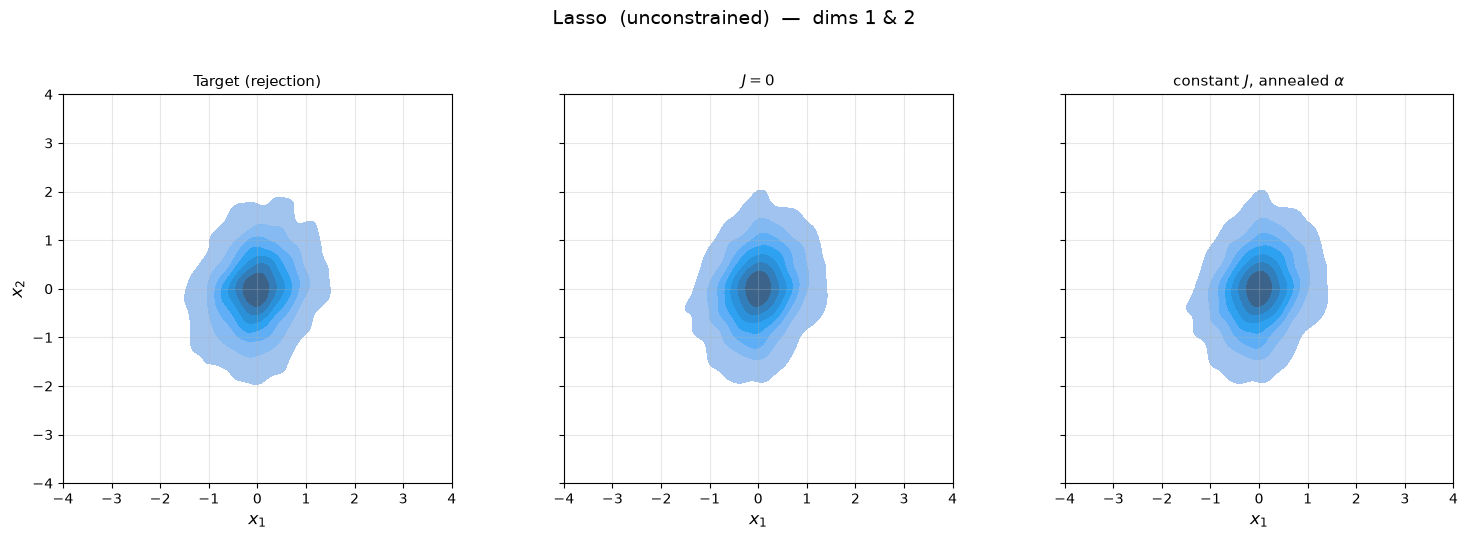

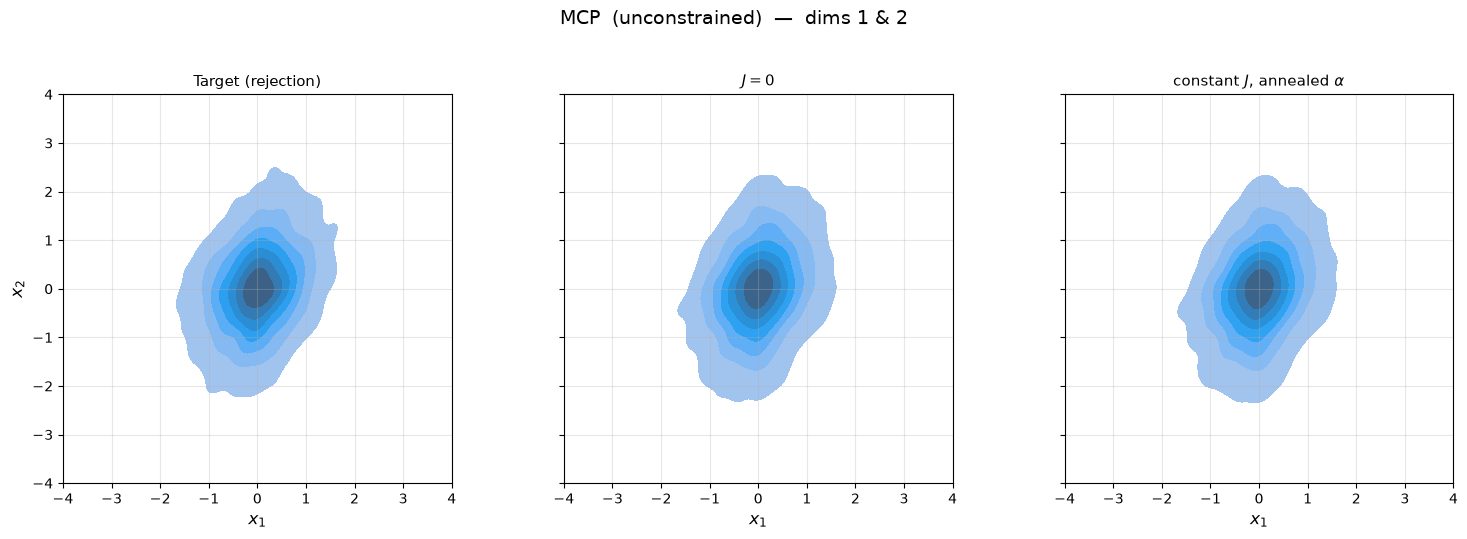

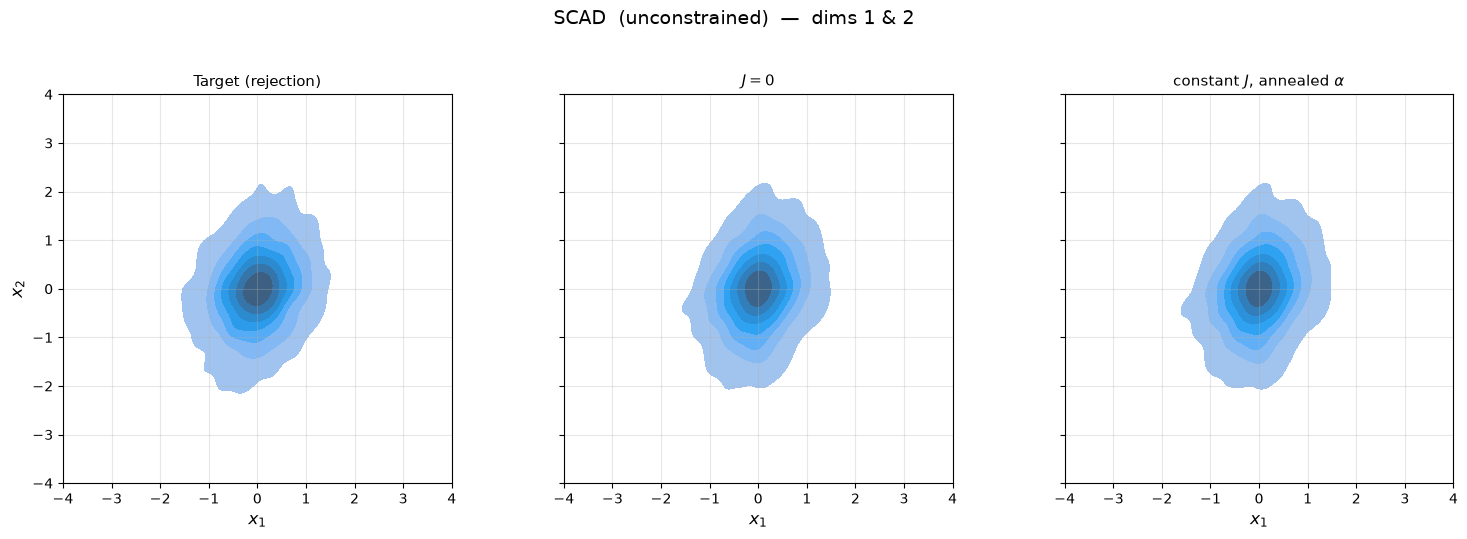

In [12]:
for nm in PENS:
    panels = [("Target (rejection)", refs[nm])] + [(SH[l], final[nm][l]["x"]) for l in [LAB[0], LAB[2]]]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.2 * len(panels), 5), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("$x_1$", fontsize=12); ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("$x_2$", fontsize=12)
    fig.suptitle(nm + "  (unconstrained)  —  dims 1 & 2", fontsize=14, y=1.04)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig("figures/unc_density_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — did the constant $J$ move the fixed point?

In [13]:
print("{:<34}{:>12}{:>28}".format("scheme (ensemble at 6000)", "max KS", "per-coordinate W1"))
print("-" * 76)
for nm in PENS:
    print("{}   floor {:.4f}".format(nm, floors[nm]))
    for lab in LAB:
        X = final[nm][lab]["x"]
        ks = max(ks_2samp(refs[nm][:, i], X[:, i]).statistic for i in range(d))
        w = [wasserstein_distance(refs[nm][:, i], X[:, i]) for i in range(d)]
        print("{:<34}{:>12.4f}{:>28}".format("  " + lab, ks, np.array2string(np.round(w, 4))))

scheme (ensemble at 6000)               max KS           per-coordinate W1
----------------------------------------------------------------------------
Lasso   floor 0.0230
  J = 0                                 0.0257      [0.013  0.0255 0.0217]
  constant J, alpha = 2                 0.0265      [0.0162 0.0241 0.0308]
  constant J, annealed 4 -> 0           0.0248      [0.0123 0.0251 0.0233]
MCP   floor 0.0286
  J = 0                                 0.0200      [0.018  0.0243 0.0303]
  constant J, alpha = 2                 0.0267      [0.0171 0.0412 0.0327]
  constant J, annealed 4 -> 0           0.0265      [0.0229 0.0342 0.0355]
SCAD   floor 0.0250
  J = 0                                 0.0232      [0.0153 0.02   0.0282]
  constant J, alpha = 2                 0.0278      [0.0184 0.0257 0.0325]
  constant J, annealed 4 -> 0           0.0257      [0.0181 0.0227 0.0526]


## Summary

**A constant $J$ beats $J=0$ on all three regularizers, but by less than in the constrained problem.**

| | $\tau(0.15)$ | $\tau(0.10)$ | $\tau(0.06)$ | $W_1$ @ 500 | $W_1$ @ 6000 |
|---|---|---|---|---|---|
| **Lasso** $J=0$ | 1027 | 1497 | 2293 | 0.2549 | 0.0238 |
| **Lasso** $J$, $\alpha=2$ | 613 (1.7×) | 770 (1.9×) | **1030 (2.2×)** | 0.1868 | 0.0246 |
| **Lasso** $J$, annealed | **473 (2.2×)** | 847 (1.8×) | 1200 (1.9×) | **0.1447** | 0.0232 |
| **MCP** $J=0$ | 1460 | 2197 | 3543 | 0.3209 | 0.0271 |
| **MCP** $J$, $\alpha=2$ | 953 (1.5×) | **1317 (1.7×)** | **1857 (1.9×)** | 0.2660 | 0.0296 |
| **MCP** $J$, annealed | 973 (1.5×) | 1413 (1.6×) | 2480 (1.4×) | **0.2325** | 0.0296 |
| **SCAD** $J=0$ | 1070 | 1543 | 2277 | 0.2685 | 0.0207 |
| **SCAD** $J$, $\alpha=2$ | **713 (1.5×)** | **1000 (1.5×)** | **1567 (1.5×)** | 0.2070 | 0.0236 |
| **SCAD** $J$, annealed | 800 (1.3×) | 1070 (1.4×) | 1780 (1.3×) | **0.1914** | 0.0284 |

Best gains: **2.2× (Lasso), 1.9× (MCP), 1.5× (SCAD)**, against $2.8$–$3.1\times$ for the same comparison on
the ball. Removing the constraint *reduces* what the skew field buys, which is the opposite of what one
might guess. The reason is that on $K$ the reversible dynamics is slowed by the wall — projection repeatedly
kills the component of the drift pointing outward — and circulation along level sets is exactly what that
geometry lacks. Off the constraint there is no wall to route around, so $J$ is back to its ordinary job of
breaking detailed balance in an anisotropic Gaussian-like target, which is worth less.

**Removing $K$ removes $\psi$, and the naive replacement diverges.** With no constraint set there is no
$(\lambda-G)h$ to use. Invariance is not the obstacle — for constant skew $J$,
$\nabla\!\cdot(J\nabla\psi)=\sum_{ij}J_{ij}\partial_i\partial_j\psi=0$ for *any* $\psi$, and there is no
boundary condition — but usability is. On $K$ the factor $e^{U}$ is bounded; on $\mathbb R^3$ it is not:
measured over the Lasso target, $e^{U}$ has median $7.4$, $q_{99}=1.7\times10^{3}$ and
max $4.9\times10^{5}$. Carrying over $\nabla\psi=-x$ gives a drift $\propto e^{U}x$ that overflows to
`inf` within 400 steps (max step size literally `inf` in the table above).

Tempering fixes it: $\psi=-e^{-U_0}$ gives $\nabla\psi=e^{-U_0}\nabla U_0$, so
$$\alpha e^{U}J\nabla\psi=\alpha\,e^{U-U_0}J\nabla U_0=\alpha\,a(x)\,J\nabla U_0,$$
bounded because $a\in[0.507,1.000]$ here, and the update collapses to
$x_{k+1}=x_k-\eta\,a(I+\alpha J)\nabla U_0+\sqrt{2\eta a}\,\xi$ — **anchored non-reversible Langevin**, with
$J$ back on $\nabla U_0$. So the two formulations of these notebooks are not in conflict: on a constrained
set $J$ must act on $\nabla\psi$ to be tangential, and unconstrained the only usable $\psi$ puts it back on
$\nabla U_0$. The apparent disagreement was entirely an artefact of the boundary.

**Axis alignment matters here too**, and by the same margin: at $\tau(0.06)$ on Lasso, the tridiagonal axis
gives 1810 (1.3×) and the axis along the smallest-variance eigenvector gives 1030 (2.2×).

**Two qualifications.**

* **Annealing is no longer the right default.** On the ball it dominated, because it removed the
  boundary-overshoot penalty that large $\alpha$ incurred. Unconstrained there is no wall to overshoot, so
  that reason is gone: constant $\alpha=2$ is better at the *tight* thresholds on all three penalties
  (Lasso 1030 vs 1200, MCP 1857 vs 2480, SCAD 1567 vs 1780), while annealing is better at the *loose* ones
  and at a fixed 500-iteration budget. Pick by which regime you care about.
* **There is a small stationary cost, unlike the constrained case.** $W_1$ at 6000 iterations is a few
  percent worse with $J$ on MCP ($0.0271\to0.0296$) and SCAD ($0.0207\to0.0236$), tied on Lasso
  ($0.0238\to0.0232$–$0.0246$); max KS moves the same way ($0.0200\to0.0267$ on MCP). This is ordinary
  discretization from the larger total drift, not a broken fixed point — the schemes share the same
  invariant law by construction — but it means the unconstrained win is a transient one that should be
  taken at a finite budget, not read at stationarity. The SCAD annealed run's third coordinate
  ($0.0526$ against a floor of $0.0250$) is the one number here I would not trust from three seeds.